# Mutual Funds Analytics

## Exploratory Data Analysis (EDA)

### Bluestock Capstone Project

## 1. Import Libraries

## 2. Load Cleaned Datasets

In [34]:
# ==========================================
# Convert Date Columns
# ==========================================

nav_history["date"] = pd.to_datetime(nav_history["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folios["month"] = pd.to_datetime(folios["month"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("All date columns converted successfully.")

All date columns converted successfully.


In [35]:
# ==========================================
# Dataset Overview
# ==========================================

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category Inflows": category,
    "Industry Folios": folios,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio Holdings": holdings,
    "Benchmark": benchmark
}

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 40)
    print("Shape :", df.shape)
    print("Columns :", len(df.columns))

DATASET OVERVIEW

Fund Master
----------------------------------------
Shape : (14320, 6)
Columns : 6

NAV History
----------------------------------------
Shape : (46000, 3)
Columns : 3

AUM
----------------------------------------
Shape : (90, 5)
Columns : 5

SIP
----------------------------------------
Shape : (48, 6)
Columns : 6

Category Inflows
----------------------------------------
Shape : (144, 3)
Columns : 3

Industry Folios
----------------------------------------
Shape : (21, 6)
Columns : 6

Performance
----------------------------------------
Shape : (40, 19)
Columns : 19

Transactions
----------------------------------------
Shape : (32778, 13)
Columns : 13

Portfolio Holdings
----------------------------------------
Shape : (322, 8)
Columns : 8

Benchmark
----------------------------------------
Shape : (8050, 3)
Columns : 3


In [36]:
# ==========================================
# Load Cleaned Datasets
# ==========================================

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folios = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [37]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Dataset Overview

## 4. NAV Trend Analysis

In [38]:
# ==========================================
# NAV Dataset Overview
# ==========================================

print(nav_history.head())

print("\nShape:")
print(nav_history.shape)

print("\nColumns:")
print(nav_history.columns)

print("\nUnique Funds:")
print(nav_history["amfi_code"].nunique())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639

Shape:
(46000, 3)

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

Unique Funds:
40


In [43]:
# ==========================================
# Merge Scheme Names
# ==========================================

nav_history["amfi_code"] = nav_history["amfi_code"].astype(str)
fund_master["scheme_code"] = fund_master["scheme_code"].astype(str)

nav_history = nav_history.merge(
    fund_master[["scheme_code", "scheme_name"]],
    left_on="amfi_code",
    right_on="scheme_code",
    how="left"
)

nav_history.head()

,amfi_code,date,nav,scheme_code_x,scheme_name_x,scheme_code_y,scheme_name_y
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,NaN,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,NaN,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,NaN,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,NaN,NaN,NaN,NaN


In [45]:
print(nav_history.columns)

print(nav_history.columns)

if "scheme_name" not in nav_history.columns:
    if "scheme_name_y" in nav_history.columns:
        nav_history = nav_history.rename(columns={"scheme_name_y": "scheme_name"})
    elif "scheme_name_x" in nav_history.columns:
        nav_history = nav_history.rename(columns={"scheme_name_x": "scheme_name"})

print(nav_history["scheme_name"].isnull().sum())

Index(['amfi_code', 'date', 'nav', 'scheme_code_x', 'scheme_name_x',
       'scheme_code_y', 'scheme_name_y'],
      dtype='str')
Index(['amfi_code', 'date', 'nav', 'scheme_code_x', 'scheme_name_x',
       'scheme_code_y', 'scheme_name_y'],
      dtype='str')
12650


In [49]:
import os

os.makedirs("../reports/charts", exist_ok=True)

fig.write_html("../reports/charts/nav_trend.html")
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)"
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    height=700,
    width=1300
)

fig.show()

## 5. AUM Growth Analysis

In [56]:
# ==========================================
# AUM Dataset Overview
# ==========================================

print(aum.head())

print("\nShape:")
print(aum.shape)

print("\nColumns:")
print(aum.columns)

print("\nMissing Values:")
print(aum.isnull().sum())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  

Shape:
(90, 6)

Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='str')

Missing Values:
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
year              0
dtype: int64


In [57]:
# ==========================================
# Extract Year
# ==========================================

aum["date"] = pd.to_datetime(aum["date"], errors="coerce")
aum["year"] = aum["date"].dt.year

print(aum[["date", "year"]].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


In [58]:
print(aum["fund_house"].unique())

<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str


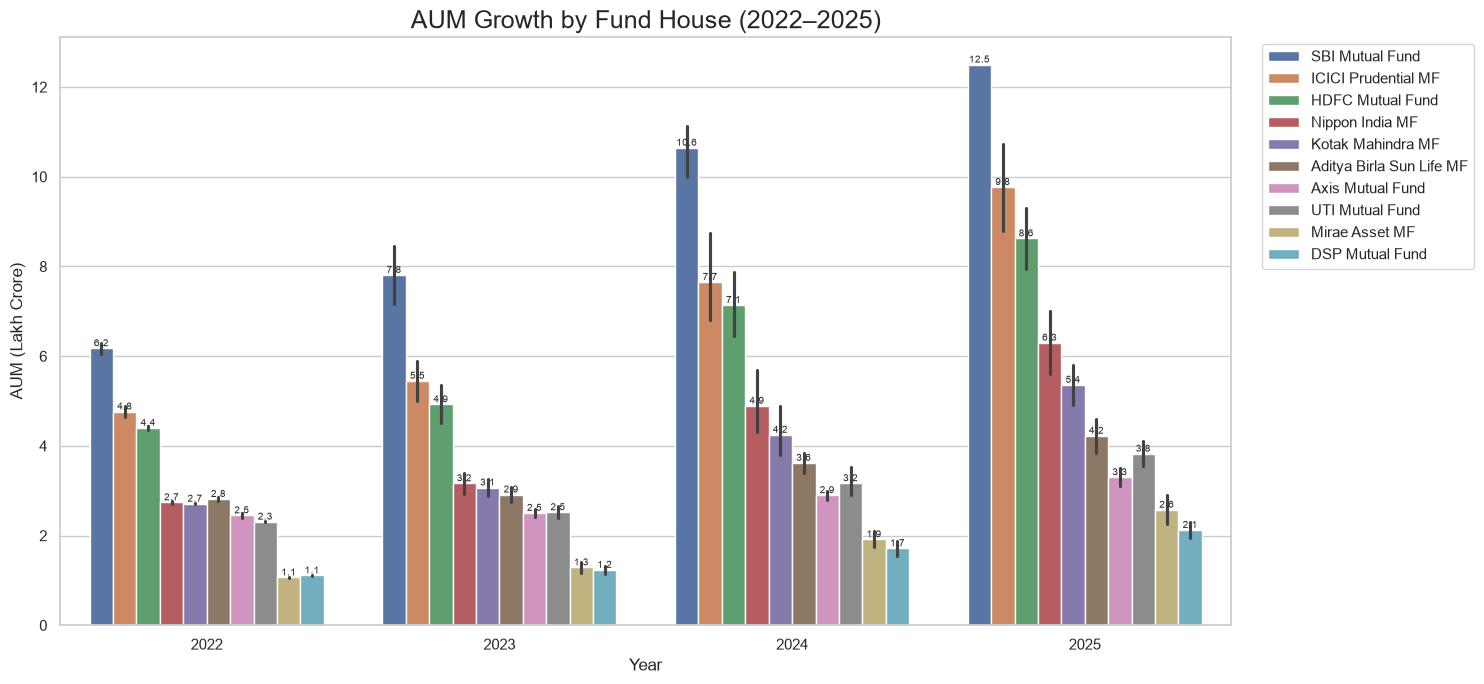

In [59]:
plt.figure(figsize=(15,7))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=18
)

plt.xlabel("Year")

plt.ylabel("AUM (Lakh Crore)")

# Highlight SBI
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=7)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

### Insight 1

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) during the study period (2022–2025), reaching approximately ₹12.5 lakh crore by the end of 2025. This indicates strong investor confidence and sustained market leadership.

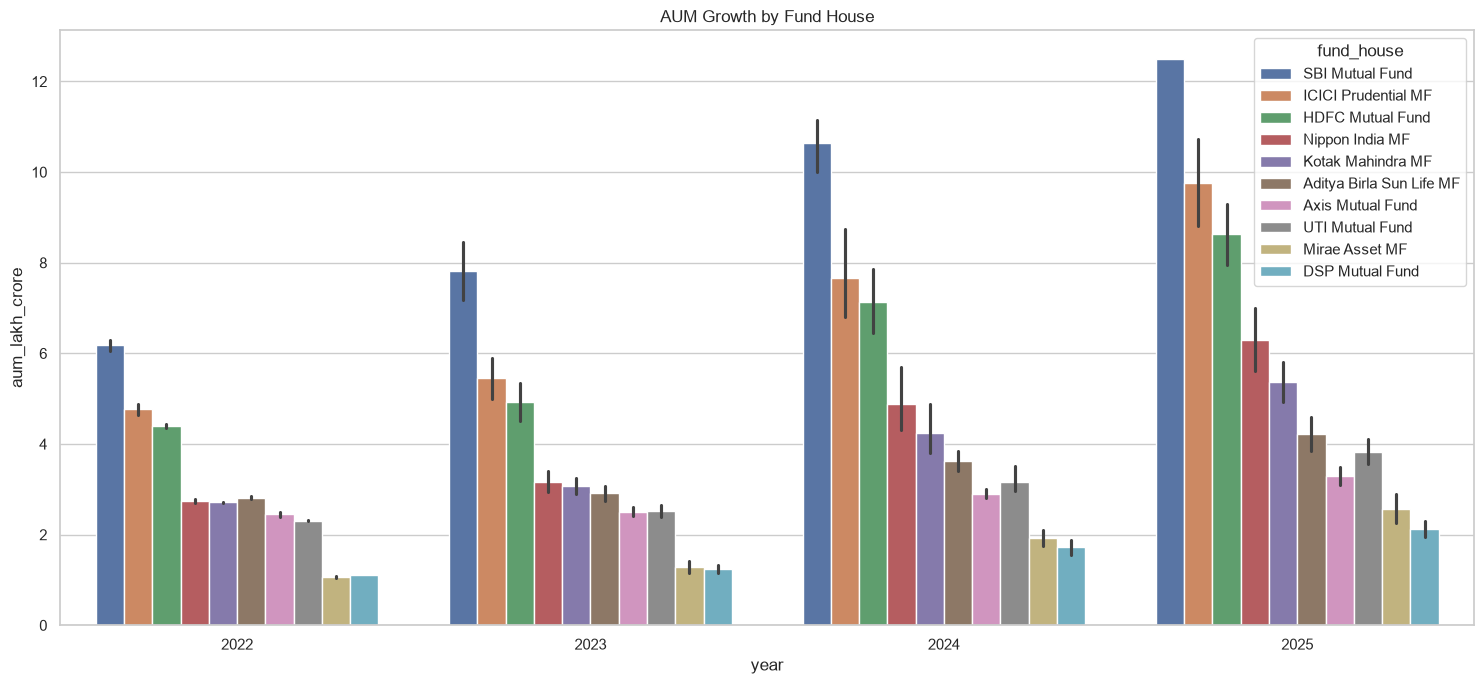

In [60]:
import os

os.makedirs("../reports/charts", exist_ok=True)

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300
)

plt.show()

## 6. SIP Inflow Analysis

In [61]:
# ==========================================
# SIP Dataset Overview
# ==========================================

print(sip.head())

print("\nShape:")
print(sip.shape)

print("\nColumns:")
print(sip.columns)

print("\nData Types:")
print(sip.dtypes)

print("\nMissing Values:")
print(sip.isnull().sum())

        month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01-01             11517                       4.91   
1  2022-02-01             11438                       4.93   
2  2022-03-01             12328                       5.09   
3  2022-04-01             11863                       5.48   
4  2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Shape:
(48, 6)

Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Data Types:
month                            str
sip_inflow_crore

In [62]:
print(sip["month"].head())

print(sip["month"].dtype)

0    2022-01-01
1    2022-02-01
2    2022-03-01
3    2022-04-01
4    2022-05-01
Name: month, dtype: str
str


In [63]:
# Maximum SIP Inflow

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(max_row)

month                        2025-12-01
sip_inflow_crore                  31002
active_sip_accounts_crore          9.35
new_sip_accounts_lakh               9.8
sip_aum_lakh_crore                 15.9
yoy_growth_pct                    17.17
Name: 47, dtype: object


In [ ]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

# Highlight highest SIP

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="₹31,002 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    height=600,
    width=1200
)

fig.show()

## 7. Category Inflow Analysis

## 8. Investor Demographics

## 9. Geographic Analysis

## 10. Correlation Analysis

## 11. Portfolio Sector Allocation

## 12. Key Insights